In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from functools import reduce #for counting iterations
import pandas as pd

In [2]:
#list
random_seeds = [12,24,32,42,58,12_1]
#accuracies = [0.97826087,0.98136646,0.987654321,0.981481481,0.965838509,0.975308642]
precision=[0.861111111,0.857142857,1,0.943396226,0.785714286,0.8]


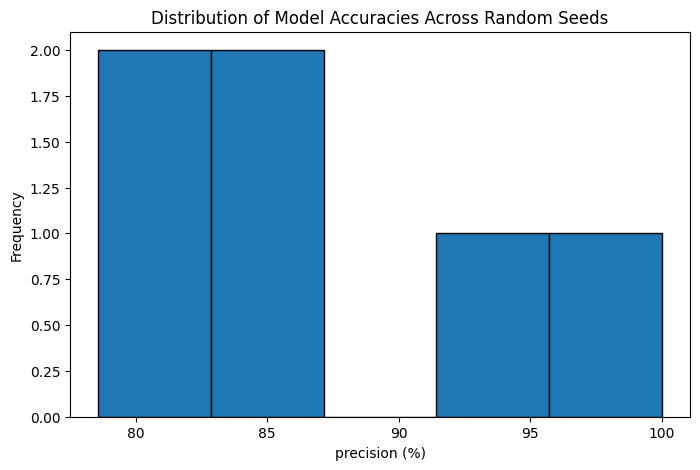

In [3]:
# Convert accuracy to percentage
#accuracies_percent = [acc * 100 for acc in accuracies]
pre_percent=[pre* 100 for pre in precision] 
#histogram plot
plt.figure(figsize=(8, 5))

plt.hist(
    pre_percent,
    bins=5,
    edgecolor='black'
)

plt.xlabel("precision (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Model Accuracies Across Random Seeds")

plt.show()

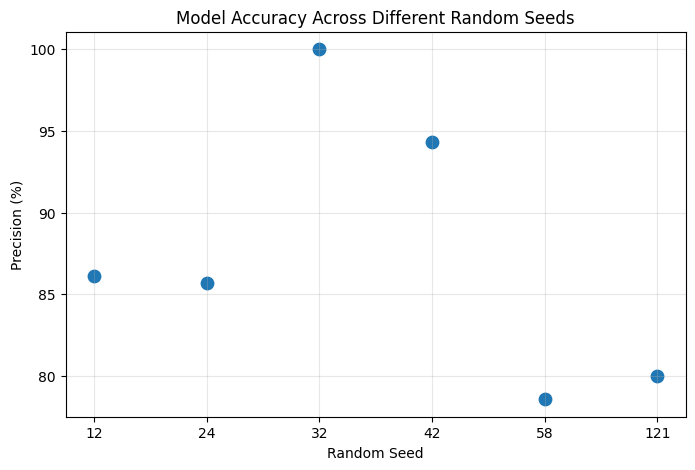

In [12]:
#scatter plot accuracy vs seeds

#random_seeds = [12, 24, 32, 42, 58, 12_1]
#accuracies = [0.97826087, 0.98136646, 0.987654321, 0.981481481, 0.965838509, 0.975308642]

#accuracies_percent = [acc * 100 for acc in accuracies]

plt.figure(figsize=(8, 5))

plt.scatter(range(len(random_seeds)), pre_percent, s=80)

plt.xticks(range(len(random_seeds)), random_seeds)
plt.xlabel("Random Seed")
plt.ylabel("Precision (%)")
plt.title("Model Accuracy Across Different Random Seeds")

plt.grid(True, alpha=0.3)
plt.show()

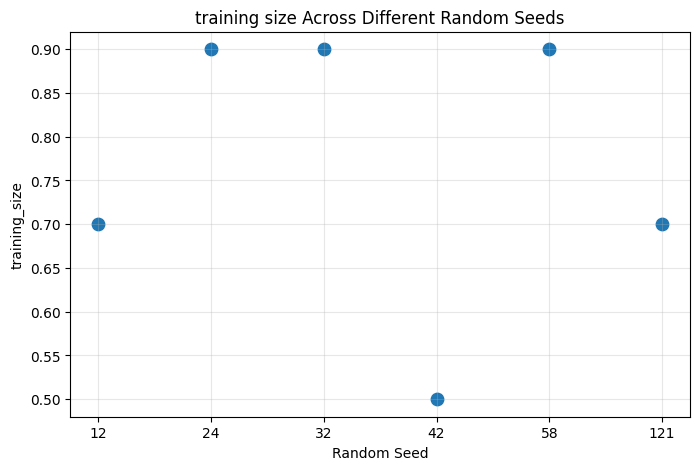

In [5]:
#scatter plot, training vs seeds

random_seeds = [12, 24, 32, 42, 58, 12_1]
training_size = [0.7, 0.9, 0.9, 0.5, 0.9, 0.7]

#training_size_percent = [training_size * 100 for acc in accuracies]

plt.figure(figsize=(8, 5))

plt.scatter(range(len(random_seeds)), training_size, s=80)

plt.xticks(range(len(random_seeds)), random_seeds)
plt.xlabel("Random Seed")
plt.ylabel("training_size")
plt.title("training size Across Different Random Seeds")

plt.grid(True, alpha=0.3)
plt.show()

In [6]:
#output files for best models
files = {
    "RS_12": "best_model_prediction_cv_candidates_above_0.9_RS_12.csv",
    "RS_24": "best_model_prediction_cv_candidates_above_0.9_RS_24.csv",
    "RS_32": "best_model_prediction_cv_candidates_above_0.9_RS_36.csv",
    "RS_42": "best_model_prediction_cv_candidates_above_0.9_RS_42.csv",
    "RS_58": "best_model_prediction_cv_candidates_above_0.9_RS_58.csv",
    "RS_12_1": "best_model_prediction_cv_candidates_above_0.9_RS_12_1.csv"
}

# Read each CSV
dfs = {}

for name, file in files.items():
    df = pd.read_csv(file)
    
    # Keep objectId and CV probability
   
    df = df[["objectId", "cv_probability"]].copy()
    
    # Rename probability column according to random seed
    df = df.rename(columns={
        "cv_probability": f"CV_probability_{name}"
    })
    
    dfs[name] = df


# Merge all files using OUTER JOIN
# This keeps every unique objectId
merged_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="objectId",
        how="outer"
    ),
    dfs.values()
)



# Find how many files each object appears in


probability_columns = [
    col for col in merged_df.columns
    if col.startswith("CV_probability_")
]

merged_df["number_of_files"] = (
    merged_df[probability_columns]
    .notna()
    .sum(axis=1)
)



# Create a column showing which files contain each object

def find_common_files(row):
    common_files = []
    
    for name in files.keys():
        column = f"CV_probability_{name}"
        
        if pd.notna(row[column]):
            common_files.append(name)
    
    return ", ".join(common_files)


merged_df["common_in_files"] = merged_df.apply(
    find_common_files,
    axis=1
)



# Sort by number of files
# 6 files first, then 5, 4, 3, 2, 1


merged_df = merged_df.sort_values(
    by="number_of_files",
    ascending=False
)



# Keep only objects common to at least 2 files


common_objects = merged_df[
    merged_df["number_of_files"] >= 2
].copy()


# Save the result


common_objects.to_csv(
    "common_MCV_candidates_2_to_6_files_best_model.csv",
    index=False
)


print(
    f"Total objects common to at least 2 files: "
    f"{len(common_objects)}"
)

#print(
 #   common_objects[
  #      ["objectId", "number_of_files", "common_in_files"]
  #  ].head(20)
#)

Total objects common to at least 2 files: 724


In [7]:
df=pd.read_csv("common_MCV_candidates_2_to_6_files_best_model.csv")

In [8]:
df

,objectId,CV_probability_RS_12,CV_probability_RS_24,CV_probability_RS_32,CV_probability_RS_42,CV_probability_RS_58,CV_probability_RS_12_1,number_of_files,common_in_files
0,ZTF17aaaadkj,0.993517,0.997475,0.950426,0.965928,0.994545,0.982554,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
1,ZTF18aczddtb,0.998768,0.998145,0.932407,0.994231,0.996592,0.995741,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
2,ZTF18abscjio,0.998649,0.998270,0.954888,0.993471,0.999410,0.996596,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
3,ZTF18abshook,0.995070,0.997508,0.910162,0.994658,0.973226,0.995260,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
4,ZTF18abtgioa,0.993437,0.998803,0.947081,0.996107,0.997068,0.995712,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
...,...,...,...,...,...,...,...,...,...
719,ZTF18achnnpz,NaN,NaN,NaN,NaN,0.969250,0.980011,2,"RS_58, RS_12_1"
720,ZTF18abkjgcu,0.964752,NaN,NaN,NaN,0.948895,NaN,2,"RS_12, RS_58"
721,ZTF18acnocdo,NaN,NaN,NaN,0.933733,0.965038,NaN,2,"RS_42, RS_58"
722,ZTF18abdeygt,NaN,0.961218,NaN,NaN,NaN,0.923988,2,"RS_24, RS_12_1"


In [9]:
#output files for previously saved models
files = {
    "RS_12": "cv_candidates_above_0.9_for_previously_saved_model_RS_12.csv",
    "RS_24": "cv_candidates_above_0.9_for_previously_saved_model_RS_24.csv",
    "RS_32": "cv_candidates_above_0.9_for_previously_saved_model_RS_36.csv",
    "RS_42": "cv_candidates_above_0.9_for_previously_saved_model_RS_42.csv",
    "RS_58": "cv_candidates_above_0.9_for_previously_saved_model_RS_58.csv",
    "RS_12_1": "cv_candidates_above_0.9_for_previously_saved_model_RS_12_1.csv"
}

# Read each CSV
dfs = {}

for name, file in files.items():
    df = pd.read_csv(file)
    
    # Keep objectId and CV probability
   
    df = df[["objectId", "cv_probability"]].copy()
    
    # Rename probability column according to random seed
    df = df.rename(columns={
        "cv_probability": f"CV_probability_{name}"
    })
    
    dfs[name] = df


# Merge all files using OUTER JOIN
# This keeps every unique objectId
merged_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="objectId",
        how="outer"
    ),
    dfs.values()
)



# Find how many files each object appears in


probability_columns = [
    col for col in merged_df.columns
    if col.startswith("CV_probability_")
]

merged_df["number_of_files"] = (
    merged_df[probability_columns]
    .notna()
    .sum(axis=1)
)



# Create a column showing which files contain each object

def find_common_files(row):
    common_files = []
    
    for name in files.keys():
        column = f"CV_probability_{name}"
        
        if pd.notna(row[column]):
            common_files.append(name)
    
    return ", ".join(common_files)


merged_df["common_in_files"] = merged_df.apply(
    find_common_files,
    axis=1
)



# Sort by number of files
# 6 files first, then 5, 4, 3, 2, 1


merged_df = merged_df.sort_values(
    by="number_of_files",
    ascending=False
)



# Keep only objects common to at least 2 files


common_objects = merged_df[
    merged_df["number_of_files"] >= 2
].copy()


# Save the result


common_objects.to_csv(
    "common_MCV_candidates_2_to_6_files_for_previously_saved_model.csv",
    index=False
)


print(
    f"Total objects common to at least 2 files: "
    f"{len(common_objects)}"
)

#print(
 #   common_objects[
  #      ["objectId", "number_of_files", "common_in_files"]
  #  ].head(20)
#)

Total objects common to at least 2 files: 307


In [10]:
df_model=pd.read_csv("common_MCV_candidates_2_to_6_files_for_previously_saved_model.csv")
df_model

,objectId,CV_probability_RS_12,CV_probability_RS_24,CV_probability_RS_32,CV_probability_RS_42,CV_probability_RS_58,CV_probability_RS_12_1,number_of_files,common_in_files
0,ZTF19aadqmrg,0.952036,0.941057,0.924773,0.965336,0.969838,0.942222,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
1,ZTF18aahpbwz,0.946493,0.939197,0.956790,0.932600,0.962019,0.963237,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
2,ZTF18aaglptg,0.930764,0.934635,0.945132,0.921864,0.954883,0.962173,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
3,ZTF18adnclwb,0.936894,0.953655,0.970872,0.947134,0.959894,0.964103,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
4,ZTF18adorebv,0.978034,0.980851,0.972320,0.940121,0.971256,0.931077,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
...,...,...,...,...,...,...,...,...,...
302,ZTF18aalurkz,NaN,NaN,NaN,0.950884,0.925339,NaN,2,"RS_42, RS_58"
303,ZTF18abtmzoi,0.938729,NaN,NaN,0.911315,NaN,NaN,2,"RS_12, RS_42"
304,ZTF18aagsenq,NaN,NaN,NaN,NaN,0.912577,0.945106,2,"RS_58, RS_12_1"
305,ZTF18abtrvrd,NaN,NaN,0.908132,0.921138,NaN,NaN,2,"RS_32, RS_42"


In [11]:
df_model

,objectId,CV_probability_RS_12,CV_probability_RS_24,CV_probability_RS_32,CV_probability_RS_42,CV_probability_RS_58,CV_probability_RS_12_1,number_of_files,common_in_files
0,ZTF19aadqmrg,0.952036,0.941057,0.924773,0.965336,0.969838,0.942222,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
1,ZTF18aahpbwz,0.946493,0.939197,0.956790,0.932600,0.962019,0.963237,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
2,ZTF18aaglptg,0.930764,0.934635,0.945132,0.921864,0.954883,0.962173,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
3,ZTF18adnclwb,0.936894,0.953655,0.970872,0.947134,0.959894,0.964103,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
4,ZTF18adorebv,0.978034,0.980851,0.972320,0.940121,0.971256,0.931077,6,"RS_12, RS_24, RS_32, RS_42, RS_58, RS_12_1"
...,...,...,...,...,...,...,...,...,...
302,ZTF18aalurkz,NaN,NaN,NaN,0.950884,0.925339,NaN,2,"RS_42, RS_58"
303,ZTF18abtmzoi,0.938729,NaN,NaN,0.911315,NaN,NaN,2,"RS_12, RS_42"
304,ZTF18aagsenq,NaN,NaN,NaN,NaN,0.912577,0.945106,2,"RS_58, RS_12_1"
305,ZTF18abtrvrd,NaN,NaN,0.908132,0.921138,NaN,NaN,2,"RS_32, RS_42"
